# Adaptive tree: random grains, interactions and static execution

This notebook separates tree construction from numerical-plan construction, then compares adaptive and uniform trees for the same reproducible grain geometry. It supports three physical interaction models independently of the P2P packing:

- point dipole → point;
- uniformly magnetised cuboid → point;
- uniformly magnetised cuboid → volume-averaged cuboid.

Each model can use ordinary P2P packing or the reduced/signed Tensor6 dictionary. The reduced cases must resolve to `TENSOR_DICTIONARY`; ordinary cases report whichever backend-specific packing is selected. Runtime inputs are total moments $m_i=V_iM_i$ in every mode.

Geometry cells work without CUDA. Benchmark cells require the selected backend; choose `CPU_STATIC` explicitly for a small smoke run.

In [ ]:
import time
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cdfmm
try:
    from adaptive_showcase import *
except ModuleNotFoundError:
    from examples.notebooks.adaptive_showcase import *

GEOMETRY_MODE = "random_grains"
N_GRAINS = 5
BASE_GRID = 5
N_REFINE = 4
SEED = 42
N_PARTICLES = 15_000  # only for the optional material_subdivision geometry

LEAF_CAPACITY = 32
MAX_DEPTH = 4
BACKEND = cdfmm.ExecutionBackend.CUDA_FULL
PRECISION = cdfmm.StaticPrecision.FLOAT32
ORDER = 6
N_EVALUATIONS = 10
RUN_FULL_SWEEP = True
BENCHMARK_INTERACTION_MODES = (INTERACTION_MODES if RUN_FULL_SWEEP else ("point-point",))
# Select one mode for a quick run, or enable the sweep for all P2P paths.
P2P_MODE = "dictionary"  # canonical, bsr, dictionary
DICTIONARY_EXECUTOR = "power2"  # source_warp, target_owned, power2
# With P2P_MODE == "bsr", optionally add exactly one reduced comparison.
RUN_BSR_COMPARISON = False
BSR_COMPARISON_REDUCED_KERNEL = "power2"  # warp, target, power2
RUN_P2P_SWEEP = False
_BSR_REDUCED_EXECUTORS = {
    "warp": "source_warp",
    "target": "target_owned",
    "power2": "power2",
}
if BSR_COMPARISON_REDUCED_KERNEL not in _BSR_REDUCED_EXECUTORS:
    raise ValueError("BSR_COMPARISON_REDUCED_KERNEL must be warp, target, or power2")
if RUN_P2P_SWEEP:
    BENCHMARK_P2P_MODES = P2P_MODES
    BENCHMARK_DICTIONARY_EXECUTORS = DICTIONARY_EXECUTORS
elif RUN_BSR_COMPARISON:
    if P2P_MODE != "bsr":
        raise ValueError("RUN_BSR_COMPARISON requires P2P_MODE = 'bsr'")
    BENCHMARK_P2P_MODES = ("bsr", "dictionary")
    BENCHMARK_DICTIONARY_EXECUTORS = (
        _BSR_REDUCED_EXECUTORS[BSR_COMPARISON_REDUCED_KERNEL],
    )
else:
    BENCHMARK_P2P_MODES = (P2P_MODE,)
    BENCHMARK_DICTIONARY_EXECUTORS = (DICTIONARY_EXECUTOR,)
REDUCED_VALUES = tuple(mode == "dictionary" for mode in BENCHMARK_P2P_MODES)
REFERENCE_TARGET_COUNT = 256
REFERENCE_RUNS = (0, -1)
SELECTED_LEAF = None
INCLUDE_ANCESTORS = True
RUN_BENCHMARK = True

## 1. Generate the random grain material

The default starts from a $5\times5\times5$ grid and places five grain centres using a fixed seed. A base cube is recursively split when its eight corners do not all belong to the same nearest grain. `N_REFINE` is the maximum number of subdivisions beyond the base grid; interior cubes remain coarse. Every final material cube supplies one centre, one side length, and one volume-weighted total moment.

Material refinement and FMM refinement are independent. The displayed cube sizes are also passed to every cuboid numerical plan in original particle order.

Geometry: random_grains; cells: 63,433; base grid: 5^3; maximum material refinement: 4
Volume: 1.0000000000000004 total moment: [-0.14265692  0.27633558  0.22458252]


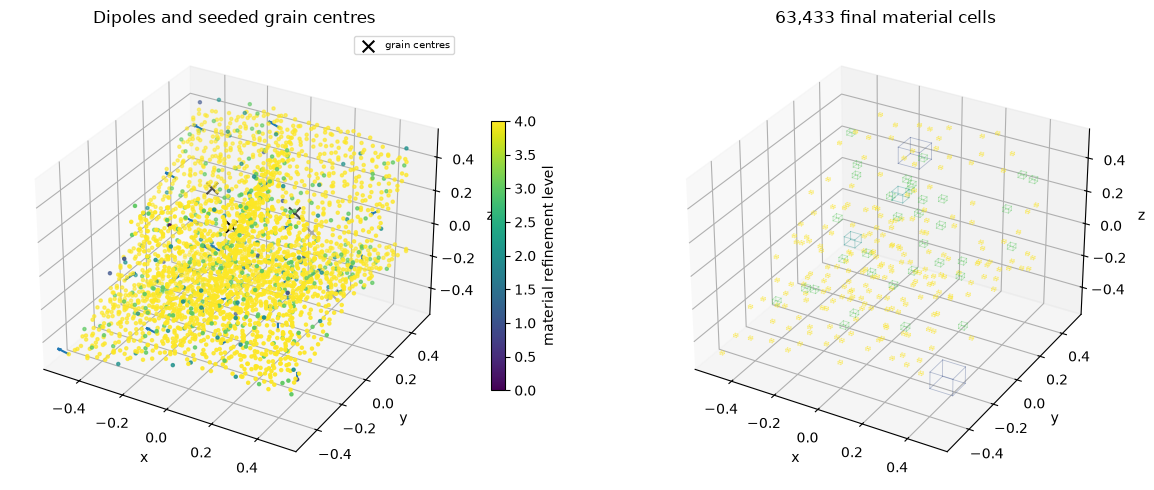

In [2]:
if GEOMETRY_MODE == "random_grains":
    material = generate_random_grains(N_GRAINS, BASE_GRID, N_REFINE, SEED)
elif GEOMETRY_MODE == "material_subdivision":
    material = generate_material(N_PARTICLES, SEED, BASE_GRID)
else:
    raise ValueError(f"unknown GEOMETRY_MODE: {GEOMETRY_MODE!r}")

positions = material["positions"]
material_levels = material["material_levels"]
print(f"Geometry: {GEOMETRY_MODE}; cells: {len(positions):,}; base grid: {BASE_GRID}^3; "
      f"maximum material refinement: {material_levels.max(initial=0)}")
print("Volume:", np.sum(material["sides"]**3),
      "total moment:", material["moments"].sum(axis=0))

fig = plt.figure(figsize=(13, 5))
axis = fig.add_subplot(121, projection="3d")
sample = np.linspace(0, len(positions)-1, min(3000, len(positions)), dtype=int)
scatter = axis.scatter(*positions[sample].T, c=material_levels[sample], s=5, cmap="viridis")
fig.colorbar(scatter, ax=axis, label="material refinement level", shrink=.6)
arrows = sample[::max(1, len(sample)//25)]
axis.quiver(*positions[arrows].T, *material["magnetisations"][arrows].T,
            length=.06, normalize=True)
if "grain_centres" in material:
    axis.scatter(*material["grain_centres"].T, marker="x", s=70, c="black",
                 linewidths=1.5, label="grain centres")
    axis.legend(fontsize=7)
finish_3d_axes(axis, "Dipoles and seeded grain centres")

axis = fig.add_subplot(122, projection="3d")
cmap = plt.get_cmap("viridis")
normalise = plt.Normalize(vmin=0, vmax=max(1, int(material_levels.max(initial=0))))
cube_sample = sample[::max(1, len(sample)//250)]
for i in cube_sample:
    draw_box_3d(axis, positions[i], material["sides"][i]/2,
                colour=cmap(normalise(material_levels[i])), alpha=.35, linewidth=.6)
finish_3d_axes(axis, "Final cells (colour = refinement level)")
axis.set_title(f"{len(positions):,} final material cells")
fig.tight_layout()

## 2. Build both trees without numerical operators

The uniform tree uses the adaptive tree's reached depth, identical root bounds, and identical particles. Leaf capacity is a split trigger rather than a guarantee at the depth cap. These objects contain geometry and connectivity only: no expansion basis, translation matrices, coefficient state, backend packing, or GPU upload has been allocated.

,nodes,leaves,reached_depth,leaves_by_level,occupancy_min,occupancy_median,occupancy_max,depth_limited,m2l,cross_level_m2l,p2p_pairs,topology_bytes
adaptive,2214,1911,4,"{2: 13, 3: 143, 4: 1755}",1,22.0,118,976,194408,7856,59887715,34238324
uniform,4681,2320,4,{4: 2320},1,11.0,118,982,276060,0,56225173,59621344


adaptive                 0.064992
uniform                  0.052127
adaptive_tree            0.019088
adaptive_interactions    0.034559
uniform_tree             0.023058
uniform_topology         0.029069
Name: seconds, dtype: float64

interactions
tree     source_level target_level              
uniform  4            4                   231240
adaptive 4            4                   149820
uniform  3            3                    41724
adaptive 3            3                    33636
         2            2                     3096
uniform  2            2                     3096
adaptive 3            4                     2684
         4            3                     2684
         2            4                     1038
         4            2                     1038
         2            3                      206
         3            2                      206

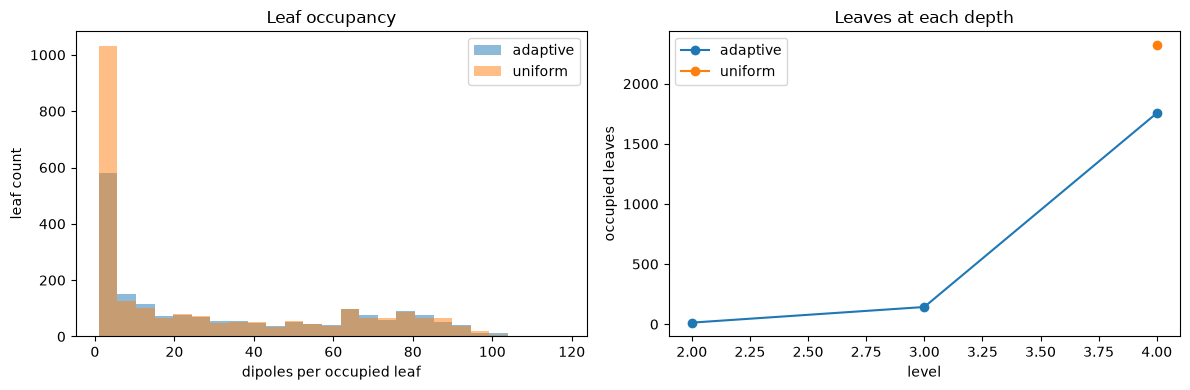

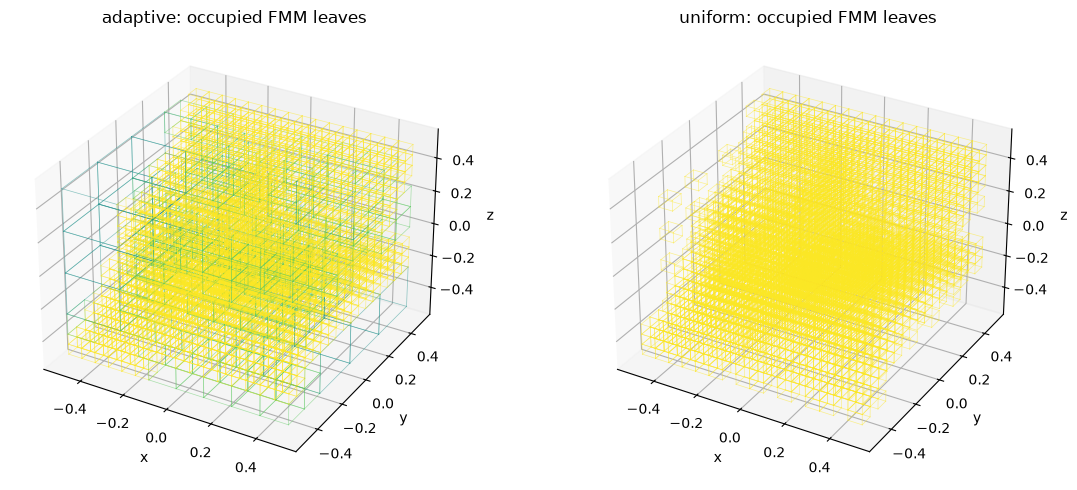

In [3]:
adaptive_tree, uniform_tree, topologies, tree_times = build_trees(
    positions, LEAF_CAPACITY, MAX_DEPTH)
summaries = {name: summarise(topology, LEAF_CAPACITY, MAX_DEPTH)
             for name, topology in topologies.items()}
display(pd.DataFrame(summaries).T)
display(pd.Series(tree_times, name="seconds"))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for name, topology in topologies.items():
    axes[0].hist([leaf.count for leaf in topology.source_leaves], bins=25,
                 alpha=.5, label=name)
    counts = summaries[name]["leaves_by_level"]
    axes[1].plot(list(counts), list(counts.values()), "o-", label=name)
axes[0].set(xlabel="dipoles per occupied leaf", ylabel="leaf count", title="Leaf occupancy")
axes[1].set(xlabel="level", ylabel="occupied leaves", title="Leaves at each depth")
for axis in axes:
    axis.legend()
plt.tight_layout()

fig = plt.figure(figsize=(12, 5))
for panel, (name, topology) in enumerate(topologies.items(), 1):
    axis = fig.add_subplot(1, 2, panel, projection="3d")
    for leaf in topology.target_leaves:
        node = topology.nodes[leaf.node]
        draw_box_3d(axis, vec3_to_array(node.centre), node.half_width,
                    colour=plt.cm.viridis(node.level/max(1, MAX_DEPTH)),
                    alpha=.5, linewidth=.5)
    finish_3d_axes(axis, f"{name}: occupied FMM leaves")
plt.tight_layout()

level_pairs = [(name, item.source_level, item.target_level)
               for name, topology in topologies.items()
               for item in topology.m2l_interactions]
if level_pairs:
    display(pd.DataFrame(level_pairs, columns=["tree", "source_level", "target_level"])
            .value_counts().rename("interactions").to_frame())

## 3. Inspect actual interaction records

Same-level M2L retains the classical list2 partition. Unequal boxes use non-touching bounds plus the convergence-safe enclosing-sphere criterion $(r_s+r_t)/d\leq0.75$. Blue and cyan show same- and unequal-level P2P; orange and purple show same- and cross-level M2L. The ancestor toggle includes M2L received by ancestors and inherited through L2L. Empty categories remain visible.

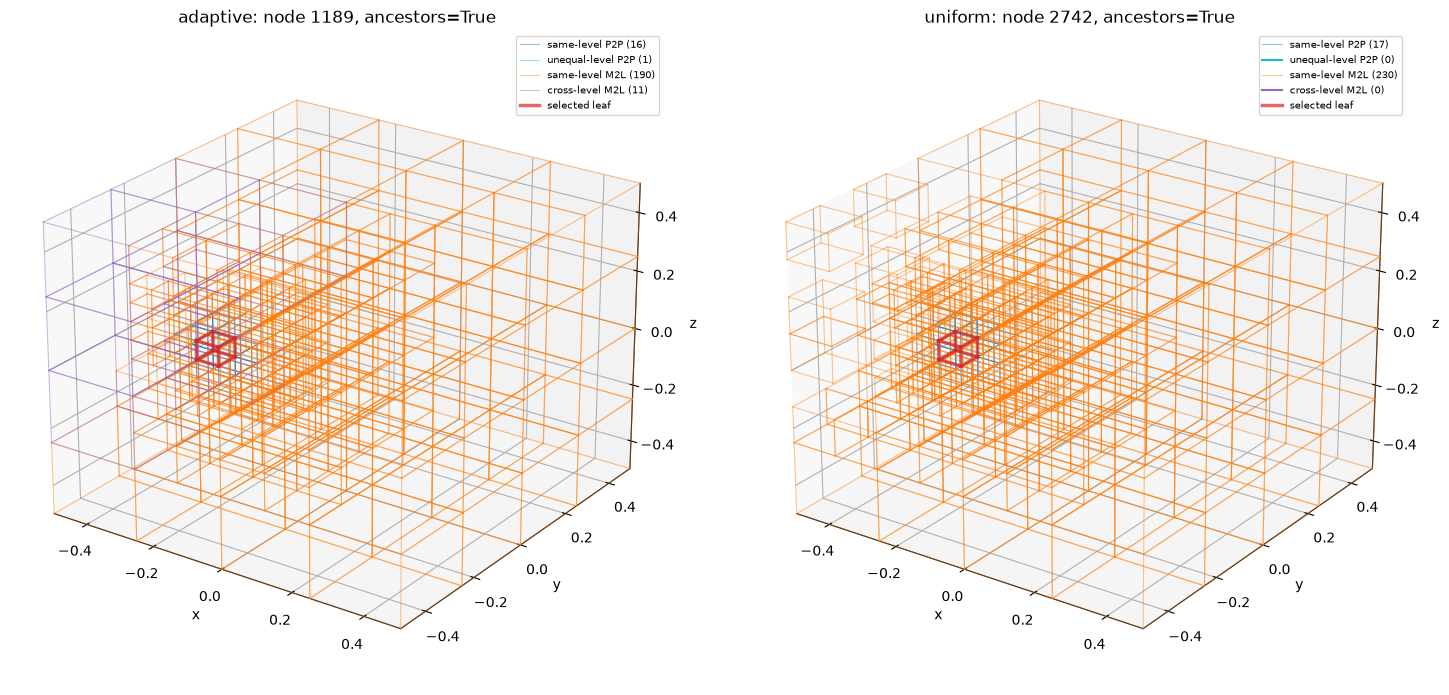

interactive(children=(Dropdown(description='selected_leaf', index=946, options=(4, 5, 6, 7, 8, 9, 10, 11, 13, …

In [4]:
selected = select_leaf(topologies["adaptive"]) if SELECTED_LEAF is None else SELECTED_LEAF

def plot_comparison(selected_leaf=selected, include_ancestors=INCLUDE_ANCESTORS):
    adaptive_node = topologies["adaptive"].nodes[selected_leaf]
    uniform_id = matching_node(topologies["uniform"], adaptive_node)
    fig = plt.figure(figsize=(15, 7))
    for panel, name, node_id in [(1, "adaptive", selected_leaf),
                                 (2, "uniform", uniform_id)]:
        axis = fig.add_subplot(1, 2, panel, projection="3d")
        draw_interactions(axis, topologies[name], node_id, include_ancestors)
        axis.set_title(f"{name}: node {node_id}, ancestors={include_ancestors}")
    plt.tight_layout()
    plt.show()

plot_comparison()
try:
    import ipywidgets as widgets
    choices = [leaf.node for leaf in topologies["adaptive"].target_leaves
               if topologies["adaptive"].nodes[leaf.node].level ==
               adaptive_tree.topology.maximum_level]
    widgets.interact(
        plot_comparison,
        selected_leaf=widgets.Dropdown(options=choices, value=selected),
        include_ancestors=widgets.Checkbox(value=INCLUDE_ANCESTORS),
    )
except ImportError:
    print("ipywidgets unavailable; edit SELECTED_LEAF and INCLUDE_ANCESTORS above.")

## 4. Build and benchmark the numerical plans

This is the first operator-allocation step. The case matrix is
`tree × BENCHMARK_INTERACTION_MODES × BENCHMARK_P2P_MODES`, with each dictionary case expanded over `BENCHMARK_DICTIONARY_EXECUTORS`. Set `RUN_BSR_COMPARISON` with `P2P_MODE = "bsr"` to compare BSR against the single executor selected by `BSR_COMPARISON_REDUCED_KERNEL`. Use `RUN_FULL_SWEEP` for all physical geometries and `RUN_P2P_SWEEP` for canonical, BSR, and all three dictionary executors. The full P2P sweep takes precedence over the BSR comparison switch. The current static-plan precision is FP32. Every plan is built once, warmed once, reused for all seeded moment states, and released before the next case. Dictionary cases fail immediately unless the resolved packing is the Tensor6 dictionary; canonical and BSR cases report their resolved backend packing.

The diagnostic tables include canonical leaf rectangles, effective particle interactions, same/unequal-level work, unique tensors, dictionary tokens and widths, host/device bytes, resolved P2P executor, setup stages, wall times, and phase medians. CUDA phases may overlap and therefore need not sum to wall time.

,interaction_mode,tree,reduced,resolved_packing,resolved_p2p_executor,p2p_interactions,phase_p2p_median_seconds,phase_cuda_p2p_kernel_median_seconds,evaluation_median_seconds
0,point-point,adaptive,True,TENSOR_DICTIONARY,CUDA,59887715,0.003388,0.003388,0.004125
1,point-point,uniform,True,TENSOR_DICTIONARY,CUDA,56225173,0.001005,0.001005,0.002080


,tree,interaction_mode,reduced,requested_packing,resolved_packing,resolved_p2p_executor,p2p_interactions,p2p_unique_tensors,p2p_dictionary_tokens,p2p_dictionary_token_width_bytes,...,phase_m2l_scatter_median_seconds,phase_m2m_median_seconds,phase_moment_permutation_median_seconds,phase_multipole_reset_median_seconds,phase_p2m_median_seconds,phase_p2p_median_seconds,phase_result_unpermutation_median_seconds,phase_total_median_seconds,tree_seconds,total_setup_seconds
0,adaptive,point-point,True,TensorDictionary,TENSOR_DICTIONARY,CUDA,59887715,148497,59887715,4,...,0.0,0.000442,0.0,0.0,0.000055,0.003388,0.000004,0.003917,0.064992,21.21072
1,uniform,point-point,True,TensorDictionary,TENSOR_DICTIONARY,CUDA,56225173,44521,56225173,2,...,0.0,0.000428,0.0,0.0,0.000057,0.001005,0.000004,0.001865,0.052127,15.61959


,comparison,interaction_mode,reduced,evaluation_ratio,p2p_phase_ratio,cuda_p2p_kernel_ratio,plan_setup_ratio,p2p_interaction_ratio,p2p_storage_ratio
0,adaptive / uniform,point-point,True,1.982631,3.372579,3.372579,1.358328,1.065141,2.134675


,tree,interaction_mode,reduced,run,seconds
0,adaptive,point-point,True,0,0.004129
1,adaptive,point-point,True,1,0.004121
2,adaptive,point-point,True,2,0.004016
3,adaptive,point-point,True,3,0.004109
4,adaptive,point-point,True,4,0.004006
5,adaptive,point-point,True,5,0.004173
6,adaptive,point-point,True,6,0.004209
7,adaptive,point-point,True,7,0.004169
8,adaptive,point-point,True,8,0.004134
9,adaptive,point-point,True,9,0.004030


,tree,interaction_mode,reduced,run,moment_permutation,multipole_reset,p2m,m2m,local_reset,m2l,...,cuda_kernel,cuda_d2h,cuda_m2l_h2d,cuda_m2l_d2h,cuda_p2p_h2d,cuda_p2p_kernel,cuda_p2p_d2h,cuda_p2p_wait,total,evaluations
0,adaptive,point-point,True,0,0.0,0.0,0.000055,0.000442,0.0,0.000717,...,0.004748,0.000032,0.0,0.0,0.0,0.003393,0.0,0.0,0.003923,1
1,adaptive,point-point,True,1,0.0,0.0,0.000055,0.000440,0.0,0.000750,...,0.004787,0.000030,0.0,0.0,0.0,0.003401,0.0,0.0,0.003923,1
2,adaptive,point-point,True,2,0.0,0.0,0.000055,0.000442,0.0,0.000709,...,0.004634,0.000031,0.0,0.0,0.0,0.003287,0.0,0.0,0.003815,1
3,adaptive,point-point,True,3,0.0,0.0,0.000055,0.000444,0.0,0.000698,...,0.004722,0.000032,0.0,0.0,0.0,0.003383,0.0,0.0,0.003911,1
4,adaptive,point-point,True,4,0.0,0.0,0.000055,0.000442,0.0,0.000723,...,0.004642,0.000036,0.0,0.0,0.0,0.003281,0.0,0.0,0.003807,1
5,adaptive,point-point,True,5,0.0,0.0,0.000055,0.000444,0.0,0.000678,...,0.004767,0.000032,0.0,0.0,0.0,0.003449,0.0,0.0,0.003971,1
6,adaptive,point-point,True,6,0.0,0.0,0.000055,0.000442,0.0,0.000688,...,0.004777,0.000032,0.0,0.0,0.0,0.003449,0.0,0.0,0.003970,1
7,adaptive,point-point,True,7,0.0,0.0,0.000057,0.000442,0.0,0.000700,...,0.004761,0.000034,0.0,0.0,0.0,0.003420,0.0,0.0,0.003934,1
8,adaptive,point-point,True,8,0.0,0.0,0.000055,0.000442,0.0,0.000766,...,0.004787,0.000036,0.0,0.0,0.0,0.003382,0.0,0.0,0.003898,1
9,adaptive,point-point,True,9,0.0,0.0,0.000055,0.000442,0.0,0.000764,...,0.004692,0.000030,0.0,0.0,0.0,0.003289,0.0,0.0,0.003809,1


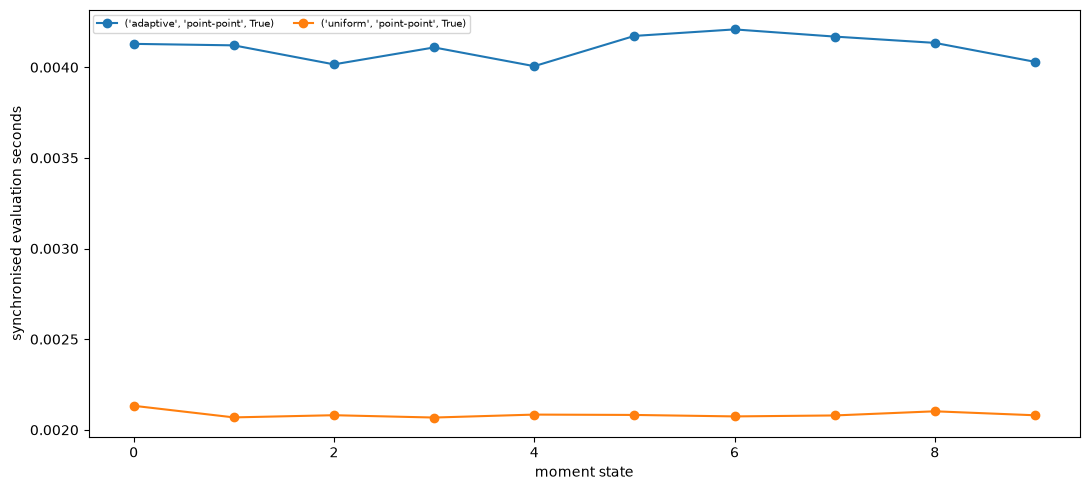

In [5]:
backend_available = (BACKEND != cdfmm.ExecutionBackend.CUDA_FULL or
                     cdfmm.cuda_full_available())
can_benchmark = RUN_BENCHMARK and backend_available
if not can_benchmark:
    print("Numerical cells skipped. Use a working CUDA device or explicitly select CPU_STATIC.")
else:
    states = moment_states(material, N_EVALUATIONS, SEED + 1)
    # benchmark calls plan.evaluate_components only for REFERENCE_RUNS.
    plan_setup, measurements, fields, diagnostics, component_fields = benchmark(
        topologies, states, material, BACKEND, ORDER,
        interaction_modes=BENCHMARK_INTERACTION_MODES,
        reduced_values=REDUCED_VALUES, precision=PRECISION,
        p2p_modes=BENCHMARK_P2P_MODES,
        dictionary_executors=BENCHMARK_DICTIONARY_EXECUTORS,
        component_runs=REFERENCE_RUNS,
    )
    result_records = benchmark_summary(plan_setup, measurements, diagnostics)
    for row in result_records:
        row["tree_seconds"] = tree_times[row["tree"]]
        row["total_setup_seconds"] = row["tree_seconds"] + row["plan_setup_seconds"]
    result_table = pd.DataFrame(result_records)
    primary_columns = [
        "interaction_mode", "tree", "p2p_mode",
        "dictionary_executor", "resolved_packing",
        "resolved_p2p_executor", "p2p_interactions",
        "phase_p2p_median_seconds",
        "phase_cuda_p2p_kernel_median_seconds",
        "evaluation_median_seconds",
        "p2p_gpair_per_second", "device_bytes",
        "p2p_unique_tensors", "p2p_dictionary_token_width_bytes",
    ]
    primary_table = result_table[primary_columns]
    display(primary_table)
    display(result_table)  # Complete topology, setup and memory diagnostics.

    ratio_table = pd.DataFrame(comparison_ratios(result_records))
    display(ratio_table)

    timing_table = pd.DataFrame([
        {key: value for key, value in row.items() if key != "phases"}
        for row in measurements
    ])
    display(timing_table)
    phase_table = pd.DataFrame([
        dict(tree=row["tree"], interaction_mode=row["interaction_mode"],
             p2p_mode=row["p2p_mode"],
             dictionary_executor=row["dictionary_executor"],
             reduced=row["reduced"], run=row["run"], **row["phases"])
        for row in measurements
    ])
    display(phase_table)

    fig, axis = plt.subplots(figsize=(11, 5))
    for key, rows in timing_table.groupby(["tree", "interaction_mode",
                                          "p2p_mode",
                                          "dictionary_executor"]):
        axis.plot(rows.run, rows.seconds, "o-", label=str(key))
    axis.set(xlabel="moment state", ylabel="synchronised evaluation seconds")
    axis.legend(fontsize=7, ncol=2)
    plt.tight_layout()

## 5. Direct accuracy and far/P2P components

Direct references use all sources and a fixed sample of targets. This bounds retained dense Tensor6 storage for cuboid modes while remaining reproducible. Point mode uses the non-dense point direct executor; cuboid modes use exact FP64 cuboid dense tensors with each sampled target's actual material-cell size. Point identities remove singular self-pairs. Cuboid modes retain finite self-fields.

Adaptive and uniform near/far components generally differ because their partitions differ. Each P2P component is checked against direct summation over its own canonical leaf rows; its far component is checked against total direct minus that near reference. The total FMM error is always assessed against the matching physical direct model.

In [6]:
if can_benchmark:
    reference_indices = reference_target_indices(
        len(positions), REFERENCE_TARGET_COUNT, SEED + 2)
    reference_runs = sorted({run % len(states) for run in REFERENCE_RUNS})
    use_cuda_direct = BACKEND == cdfmm.ExecutionBackend.CUDA_FULL
    references = {}
    for mode in BENCHMARK_INTERACTION_MODES:
        reference_plan = build_direct_reference(
            material, mode, reference_indices, cuda=use_cuda_direct)
        for run in reference_runs:
            references[mode, run] = evaluate_direct_reference(
                reference_plan, states[run])
        del reference_plan
        gc.collect()

    accuracy_rows, component_rows = [], []
    benchmark_cases = sorted({(row["p2p_mode"],
                              row["dictionary_executor"])
                             for row in result_records})
    for mode in BENCHMARK_INTERACTION_MODES:
        for run in reference_runs:
            reference = references[mode, run]
            for tree in topologies:
                near_reference = direct_near(
                    topologies[tree], material, states[run], mode, reference_indices)
                for p2p_mode, dictionary_executor in benchmark_cases:
                    key = (tree, mode, p2p_mode, dictionary_executor)
                    reduced = p2p_mode == "dictionary"
                    actual = fields[key][run][reference_indices]
                    accuracy_rows.append(dict(
                        tree=tree, interaction_mode=mode,
                        p2p_mode=p2p_mode, dictionary_executor=dictionary_executor,
                        reduced=bool(reduced), run=run,
                        **field_errors(actual, reference),
                    ))
                    sampled = {name: np.asarray(value)[reference_indices]
                               for name, value in component_fields[key, run].items()}
                    scale = max(np.linalg.norm(sampled["H_total"]), 1e-30)
                    assert np.linalg.norm(sampled["H_far"] + sampled["H_p2p"] -
                                          sampled["H_total"]) <= 2e-6 * scale
                    for component, truth in [
                        ("H_p2p", near_reference),
                        ("H_far", reference - near_reference),
                    ]:
                        component_rows.append(dict(
                            tree=tree, interaction_mode=mode,
                            p2p_mode=p2p_mode, dictionary_executor=dictionary_executor,
                            reduced=bool(reduced),
                            run=run, component=component,
                            field_norm=np.linalg.norm(sampled[component]),
                            **field_errors(sampled[component], truth),
                        ))
    accuracy_table = pd.DataFrame(accuracy_rows)
    component_table = pd.DataFrame(component_rows)
    display(accuracy_table)
    display(component_table)

    difference_rows = []
    for mode in BENCHMARK_INTERACTION_MODES:
        for run in reference_runs:
            for p2p_mode, dictionary_executor in benchmark_cases:
                reduced = p2p_mode == "dictionary"
                difference_rows.append(dict(
                    comparison="adaptive - uniform", interaction_mode=mode,
                    p2p_mode=p2p_mode, dictionary_executor=dictionary_executor,
                    reduced=bool(reduced), run=run,
                    difference_norm=np.linalg.norm(
                        fields["adaptive", mode, p2p_mode, dictionary_executor][run][reference_indices] -
                        fields["uniform", mode, p2p_mode, dictionary_executor][run][reference_indices]),
                ))
            if ("canonical", "source_warp") in benchmark_cases and (
                    "dictionary", "source_warp") in benchmark_cases:
                for tree in topologies:
                    difference_rows.append(dict(
                        comparison="reduced - ordinary", tree=tree,
                        interaction_mode=mode, p2p_mode="dictionary",
                        dictionary_executor="source_warp", run=run,
                        difference_norm=np.linalg.norm(
                            fields[tree, mode, "dictionary", "source_warp"][run][reference_indices] -
                            fields[tree, mode, "canonical", "source_warp"][run][reference_indices]),
                    ))
    display(pd.DataFrame(difference_rows))

,tree,interaction_mode,reduced,run,relative_l2,absolute_rms,absolute_max
0,adaptive,point-point,True,0,0.004839,0.002134,0.010207
1,uniform,point-point,True,0,0.005517,0.002433,0.012258
2,adaptive,point-point,True,9,0.004654,0.002382,0.012057
3,uniform,point-point,True,9,0.005009,0.002564,0.013078


,tree,interaction_mode,reduced,run,component,field_norm,relative_l2,absolute_rms,absolute_max
0,adaptive,point-point,True,0,H_p2p,5.356050,4.795963e-07,1.605464e-07,5.101451e-07
1,adaptive,point-point,True,0,H_far,3.891458,8.779275e-03,2.133945e-03,1.020681e-02
2,uniform,point-point,True,0,H_p2p,4.949386,4.272349e-07,1.321594e-07,3.433255e-07
3,uniform,point-point,True,0,H_far,4.197182,9.275192e-03,2.432925e-03,1.225823e-02
4,adaptive,point-point,True,9,H_p2p,5.771259,4.726061e-07,1.704708e-07,5.300573e-07
5,adaptive,point-point,True,9,H_far,4.837392,7.882951e-03,2.382451e-03,1.205660e-02
6,uniform,point-point,True,9,H_p2p,5.435938,4.346504e-07,1.476708e-07,4.484807e-07
7,uniform,point-point,True,9,H_far,5.206862,7.881182e-03,2.563832e-03,1.307833e-02


,comparison,interaction_mode,reduced,run,difference_norm
0,adaptive - uniform,point-point,True,0,0.038479
1,adaptive - uniform,point-point,True,9,0.034402


## Reading the results

- Geometry and topology are identical across the six physics/packing cases; only numerical plans differ.
- Adaptive speed follows actual interaction counts and occupancies, not node count alone.
- Reduced and ordinary P2P should agree numerically, but their setup, memory, and execution costs can differ.
- Point, cuboid-to-point, and cuboid-to-cuboid totals describe different physical models and should not be compared as interchangeable answers.
- Component differences between adaptive and uniform plans are expected. Total errors against the matching direct reference determine accuracy.
- Changing moments reuses the plan. Changing cell sizes, topology, geometry mode, or packing rebuilds it.